# Telecom Churn Prediction

## 1. Problem and Dataset

This project uses the Telco Customer Churn dataset to predict whether a customer will leave the telecom company. This is a classification problem because the target column, Churn, has two categories: Yes or No.

## 2. Load and Inspect Data

In [1]:
from pathlib import Path

import pandas as pd

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"

df = pd.read_csv(DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 3. Data Preparation

The column `TotalCharges` should be numeric, but it is stored as text in the dataset. I convert it to numeric values and remove rows where the value is missing after conversion.

In [6]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
df_clean.isna().sum()[df_clean.isna().sum() > 0]

Missing values after converting TotalCharges:


TotalCharges    11
dtype: int64

In [7]:
df_clean = df_clean.dropna(subset=["TotalCharges"])

print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)

Shape before cleaning: (7043, 21)
Shape after cleaning: (7032, 21)


In [8]:
target_column = "Churn"

feature_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
]

X = df_clean[feature_columns]
y = df_clean[target_column]

print("Feature columns:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target column:
Churn

X shape: (7032, 12)
y shape: (7032,)


## 4. Visualization

I visualize churn by contract type because contract length may be connected to how likely a customer is to leave.

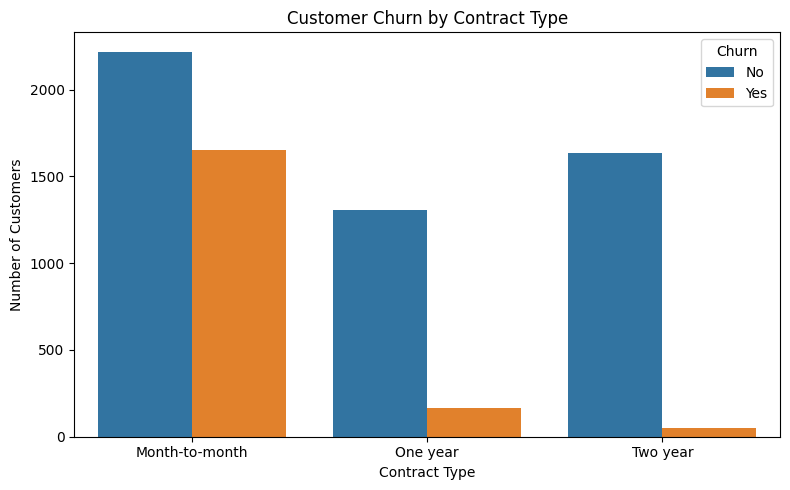

Saved plot to: c:\Users\sacco\Documents\Skola och examen\Pythonprogrammering-AI-utveckling\telecom-churn-prediction\outputs\churn_by_contract.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUTS_DIR = BASE_DIR / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df_clean, x="Contract", hue="Churn", ax=ax)

ax.set_title("Customer Churn by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Number of Customers")

fig.tight_layout()

plot_path = OUTPUTS_DIR / "churn_by_contract.png"
fig.savefig(plot_path, dpi=150)

plt.show()
plt.close(fig)

print(f"Saved plot to: {plot_path}")

The chart shows that churn is more common among month-to-month customers than among customers with longer contracts. This makes sense because month-to-month customers can leave more easily.